# EDA — EPEX-DE Benchmark (week 2)
Feeds thesis section 3-3-3 (تحلیل اکتشافی داده). Run top to bottom; figures export to `reports/figures/` in final form.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from src.data.loader import BenchmarkLoader, load_config

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
FIG_DIR = "../reports/figures"
np.random.seed(42)

cfg = load_config("../configs/data.yaml")
train, test = BenchmarkLoader(cfg).load()
df = pd.concat([train, test]).sort_index()
print(f"Train: {train.shape}  Test: {test.shape}  Combined: {df.shape}")
print(f"Range: {df.index.min()} -> {df.index.max()}")

Train: (34944, 3)  Test: (17472, 3)  Combined: (52416, 3)
Range: 2012-01-09 00:00:00 -> 2017-12-31 23:00:00


## 1. Distribution overview
Feeds: 3-3-3 distribution paragraph.

train: mean=36.20 std=15.95 skew=-0.83 kurt=19.93 negative_hours=297 (0.85%)
test: mean=31.64 std=15.49 skew=0.08 kurt=10.75 negative_hours=241 (1.38%)


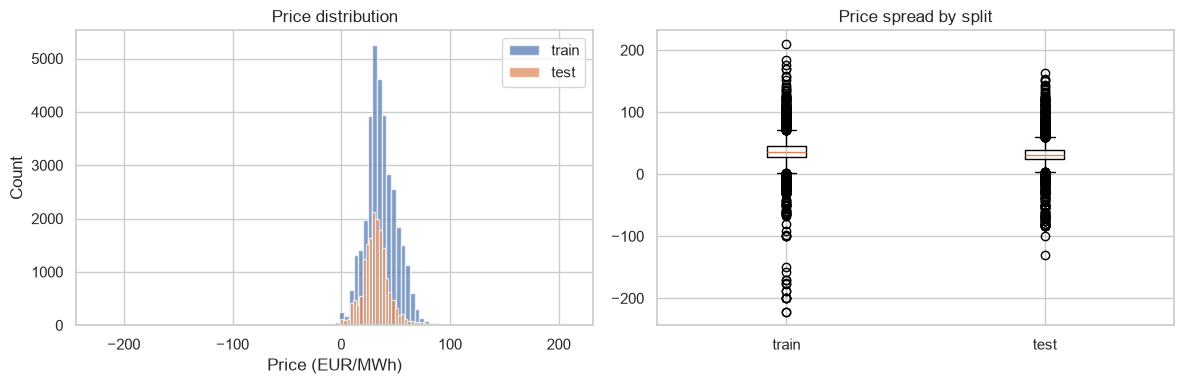

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train['price'], bins=100, alpha=0.7, label='train')
axes[0].hist(test['price'], bins=100, alpha=0.7, label='test')
axes[0].set_xlabel('Price (EUR/MWh)'); axes[0].set_ylabel('Count'); axes[0].legend()
axes[0].set_title('Price distribution')

for name, d in [('train', train), ('test', test)]:
    neg = (d['price'] < 0).sum()
    print(f"{name}: mean={d['price'].mean():.2f} std={d['price'].std():.2f} "
          f"skew={d['price'].skew():.2f} kurt={d['price'].kurt():.2f} "
          f"negative_hours={neg} ({100*neg/len(d):.2f}%)")

axes[1].boxplot([train['price'], test['price']], tick_labels=['train', 'test'])
axes[1].set_title('Price spread by split')
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_price_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

## 2. Seasonality — hourly within day
Weekday vs weekend profile. Feeds 3-3-3, 3-4 (calendar features).

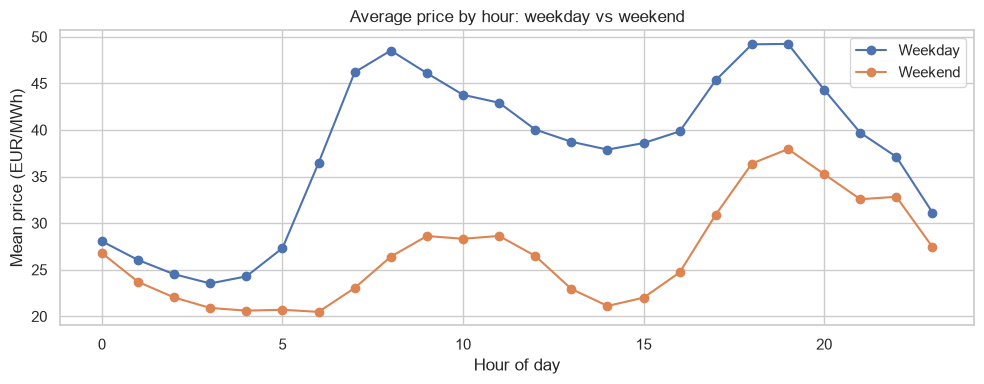

In [3]:
df['hour'] = df.index.hour
df['weekday'] = df.index.dayofweek
df['is_weekend'] = df['weekday'] >= 5

hourly = df.groupby(['hour', 'is_weekend'])['price'].mean().unstack()
hourly.columns = ['Weekday', 'Weekend']

fig, ax = plt.subplots(figsize=(10, 4))
hourly.plot(ax=ax, marker='o')
ax.set_xlabel('Hour of day'); ax.set_ylabel('Mean price (EUR/MWh)')
ax.set_title('Average price by hour: weekday vs weekend')
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_hourly_seasonality.png", dpi=300, bbox_inches='tight')
plt.show()

## 3. Seasonality — day of week

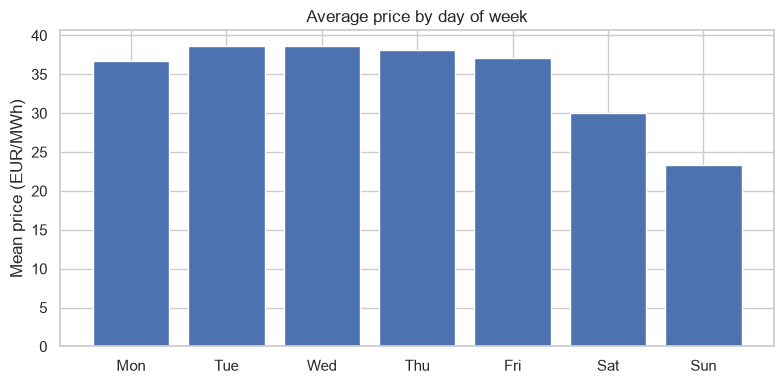

In [4]:
weekday_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
by_weekday = df.groupby('weekday')['price'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(weekday_names, by_weekday.values)
ax.set_ylabel('Mean price (EUR/MWh)')
ax.set_title('Average price by day of week')
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_weekly_seasonality.png", dpi=300, bbox_inches='tight')
plt.show()

## 4. Seasonality — annual / monthly

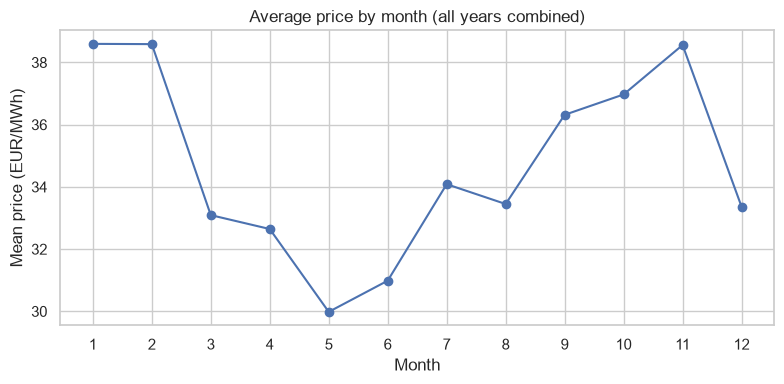

In [5]:
df['month'] = df.index.month
by_month = df.groupby('month')['price'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(by_month.index, by_month.values, marker='o')
ax.set_xticks(range(1, 13))
ax.set_xlabel('Month'); ax.set_ylabel('Mean price (EUR/MWh)')
ax.set_title('Average price by month (all years combined)')
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_annual_seasonality.png", dpi=300, bbox_inches='tight')
plt.show()

## 5. Volatility clustering + spike definition
**Decision needed**: pick and log the spike threshold in `logs/decisions.md`. Default below: mean + 3*std, computed on train only (no test leakage).

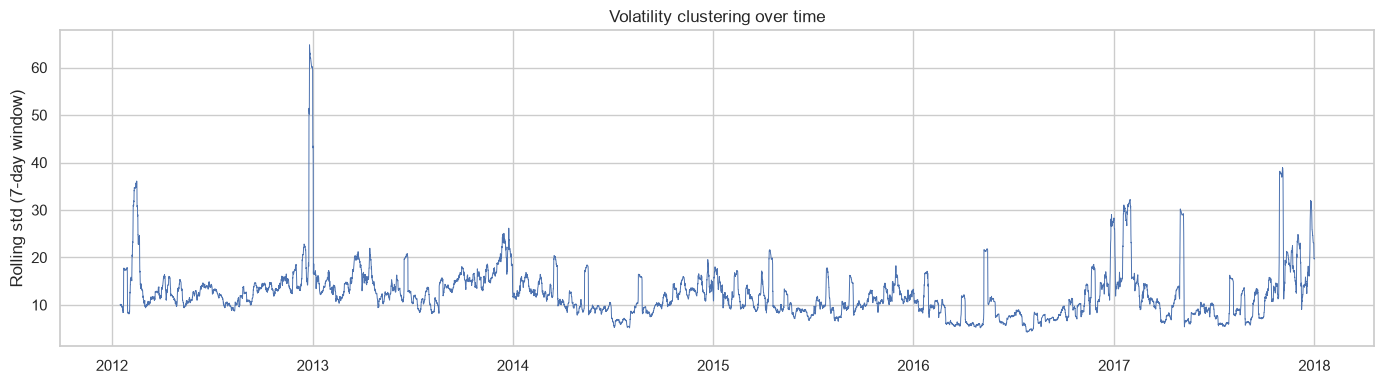

Candidate spike threshold (train mean+3std): 84.04 EUR/MWh
Spikes -> train: 180 (0.52%), test: 145 (0.83%)


In [6]:
ROLL_WINDOW = 24 * 7  # 1 week
rolling_std = df['price'].rolling(ROLL_WINDOW).std()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(rolling_std.index, rolling_std.values, linewidth=0.7)
ax.set_ylabel('Rolling std (7-day window)')
ax.set_title('Volatility clustering over time')
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_volatility_clustering.png", dpi=300, bbox_inches='tight')
plt.show()

spike_threshold = train['price'].mean() + 3 * train['price'].std()
n_spikes_train = (train['price'] > spike_threshold).sum()
n_spikes_test = (test['price'] > spike_threshold).sum()
print(f"Candidate spike threshold (train mean+3std): {spike_threshold:.2f} EUR/MWh")
print(f"Spikes -> train: {n_spikes_train} ({100*n_spikes_train/len(train):.2f}%), "
      f"test: {n_spikes_test} ({100*n_spikes_test/len(test):.2f}%)")
# TODO: log the final chosen threshold + rationale in logs/decisions.md

## 6. ACF / PACF
Annotate 24h/168h peaks — justifies week-3 lag feature choices. Feeds 3-4.

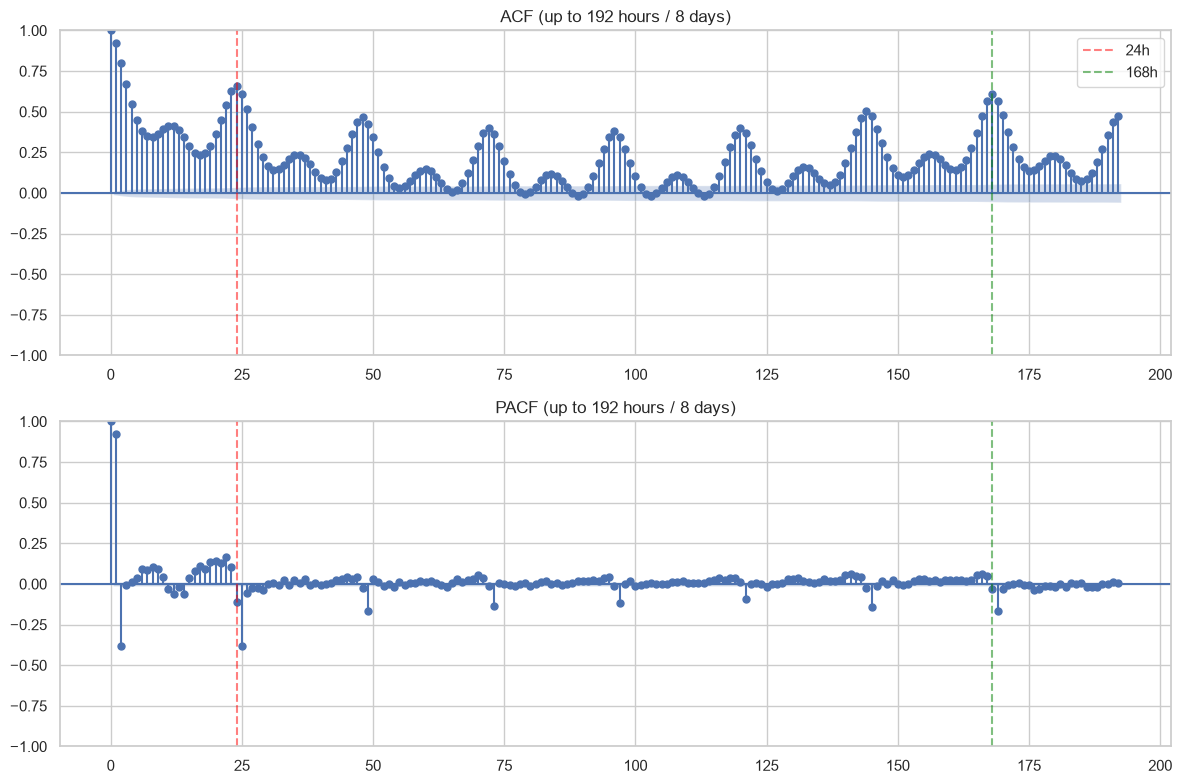

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(train['price'].dropna(), lags=192, ax=axes[0])
axes[0].set_title('ACF (up to 192 hours / 8 days)')
axes[0].axvline(24, color='red', linestyle='--', alpha=0.5, label='24h')
axes[0].axvline(168, color='green', linestyle='--', alpha=0.5, label='168h')
axes[0].legend()

plot_pacf(train['price'].dropna(), lags=192, ax=axes[1], method='ywm')
axes[1].set_title('PACF (up to 192 hours / 8 days)')
axes[1].axvline(24, color='red', linestyle='--', alpha=0.5)
axes[1].axvline(168, color='green', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_acf_pacf.png", dpi=300, bbox_inches='tight')
plt.show()

## 7. Stationarity tests (ADF, KPSS)

In [8]:
adf_stat, adf_p, *_ = adfuller(train['price'].dropna())
kpss_stat, kpss_p, *_ = kpss(train['price'].dropna(), regression='c', nlags='auto')

print(f"ADF:  statistic={adf_stat:.3f}  p-value={adf_p:.4f}  "
      f"-> {'stationary' if adf_p < 0.05 else 'NOT stationary'} (reject H0 if p<0.05)")
print(f"KPSS: statistic={kpss_stat:.3f}  p-value={kpss_p:.4f}  "
      f"-> {'stationary' if kpss_p > 0.05 else 'NOT stationary'} (fail to reject H0 if p>0.05)")

ADF:  statistic=-16.693  p-value=0.0000  -> stationary (reject H0 if p<0.05)
KPSS: statistic=8.721  p-value=0.0100  -> NOT stationary (fail to reject H0 if p>0.05)


C:\Users\win-10\AppData\Local\Temp\ipykernel_17276\3796981393.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(train['price'].dropna(), regression='c', nlags='auto')


## 8. Correlation with exogenous variables
price vs. exog_1 (load) and exog_2 (renewables).

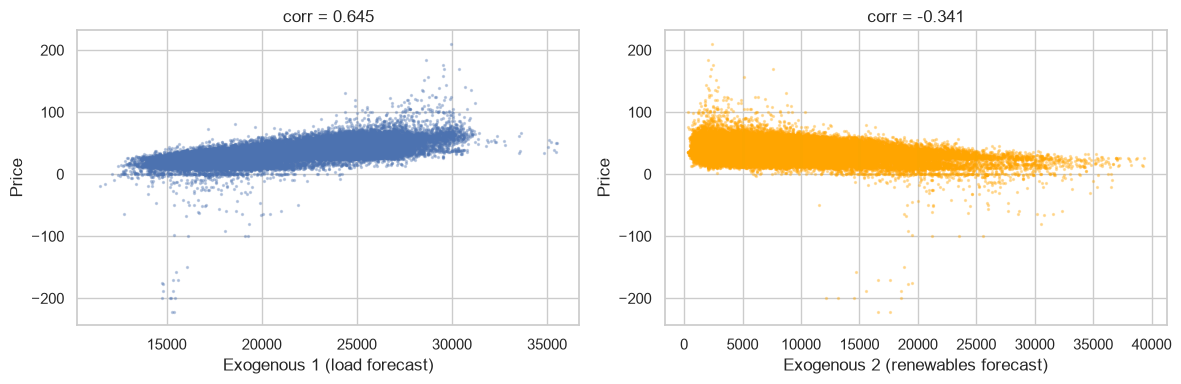

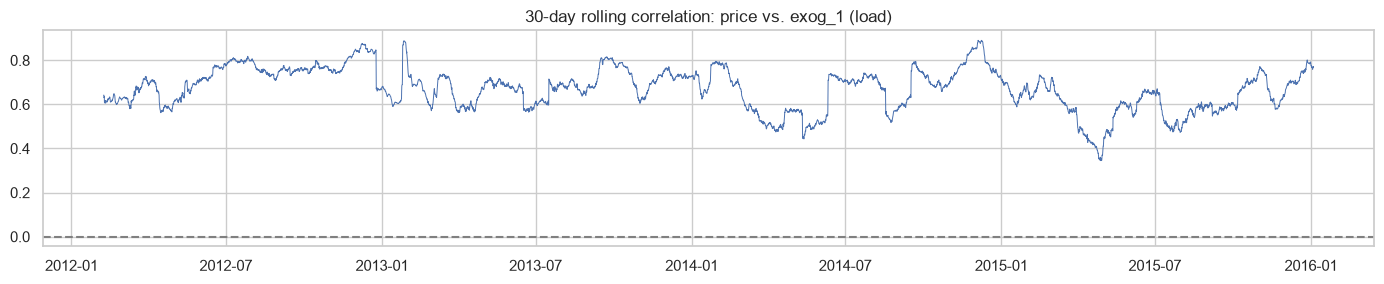

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(train['exog_1'], train['price'], s=2, alpha=0.3)
axes[0].set_xlabel('Exogenous 1 (load forecast)'); axes[0].set_ylabel('Price')
axes[0].set_title(f"corr = {train['price'].corr(train['exog_1']):.3f}")

axes[1].scatter(train['exog_2'], train['price'], s=2, alpha=0.3, color='orange')
axes[1].set_xlabel('Exogenous 2 (renewables forecast)'); axes[1].set_ylabel('Price')
axes[1].set_title(f"corr = {train['price'].corr(train['exog_2']):.3f}")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/07_exogenous_correlation.png", dpi=300, bbox_inches='tight')
plt.show()

roll_corr = train['price'].rolling(24*30).corr(train['exog_1'])
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(roll_corr.index, roll_corr.values, linewidth=0.7)
ax.axhline(0, color='gray', linestyle='--')
ax.set_title('30-day rolling correlation: price vs. exog_1 (load)')
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/07b_rolling_correlation.png", dpi=300, bbox_inches='tight')
plt.show()

## 9. Structural break check
Full span with train/test boundary marked. Feeds 5-2 (limitations).

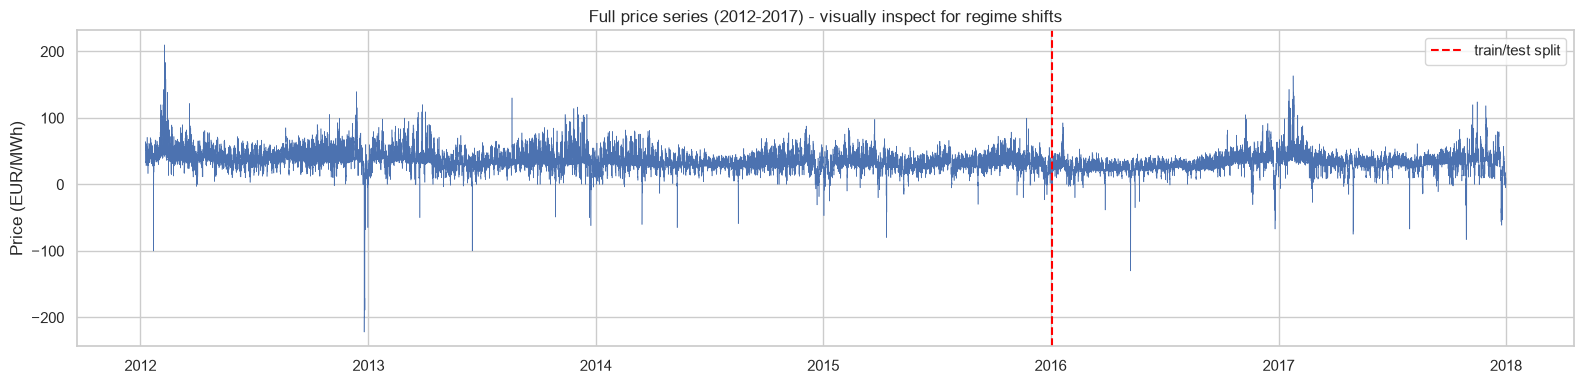

                mean        std     min     max
timestamp                                      
2012       42.889882  18.557680 -221.99  210.00
2013       37.780090  16.460232 -100.03  130.27
2014       32.763182  12.774817  -65.03   87.97
2015       31.626461  12.666899  -79.94   99.77
2016       28.979497  12.483022 -130.09  104.96
2017       34.201140  17.615172  -83.04  163.52


In [10]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df.index, df['price'], linewidth=0.4)
ax.axvline(test.index.min(), color='red', linestyle='--', label='train/test split')
ax.set_ylabel('Price (EUR/MWh)')
ax.set_title('Full price series (2012-2017) - visually inspect for regime shifts')
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/08_full_series_structural_breaks.png", dpi=300, bbox_inches='tight')
plt.show()

yearly = df.groupby(df.index.year)['price'].agg(['mean', 'std', 'min', 'max'])
print(yearly)

## 10. Daily baseload target construction
Sanity-check the aggregated daily series (used in ch.4-3, ch.4-4).

Daily series: 2184 days, 0 missing


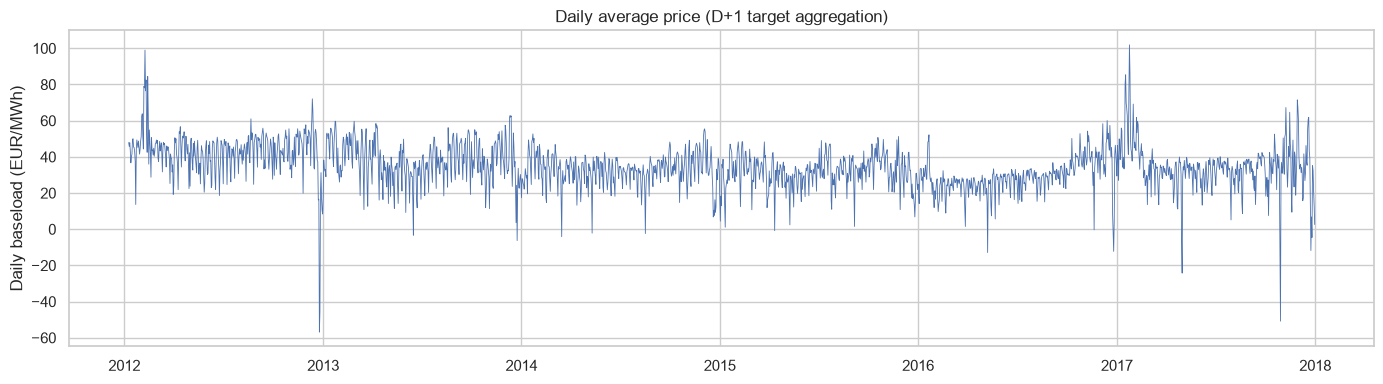

Saved -> data/processed/daily_baseload.csv


In [11]:
daily = df['price'].resample('1D').mean().rename('daily_baseload')
print(f"Daily series: {len(daily)} days, {daily.isna().sum()} missing")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily.values, linewidth=0.6)
ax.set_ylabel('Daily baseload (EUR/MWh)')
ax.set_title('Daily average price (D+1 target aggregation)')
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/09_daily_baseload.png", dpi=300, bbox_inches='tight')
plt.show()

daily.to_csv('../data/processed/daily_baseload.csv')
print("Saved -> data/processed/daily_baseload.csv")

## 11. Summary for logs/decisions.md
Copy the printed values above into the research log: spike threshold + rationale, ADF/KPSS conclusion, train/test split confirmation, any visible structural breaks.

In [12]:
print("EDA complete. Figures saved to reports/figures/.")
print("Next: copy findings into logs/decisions.md and thesis section 3-3-3.")

EDA complete. Figures saved to reports/figures/.
Next: copy findings into logs/decisions.md and thesis section 3-3-3.
